# Laboratorio 15 - Parte I: MongoDB Distribuido (Sharding)

**Dataset:** News Headlines About President Milei 
**Coleccion:** `news_analysis.milei_news`

Se implementan 5 consultas de referencia (Q1-Q5), ejecutando `explain("executionStats")` en cada una y registramos los tiempos en una tabla pandas.

Ejecutar antes:
1. `docker compose up -d`
2. `python init_cluster.py`
3. `python enable_sharding.py`
4. `python load_mongo_recursive.py`
5. `python create_indexes_mongo.py`


In [1]:
import time
import json
import pandas as pd
from pymongo import MongoClient

client = MongoClient("mongodb://localhost:28017", serverSelectionTimeoutMS=8000)
db = client["news_analysis"]
COLL = "milei_news"
coll = db[COLL]

print("Documentos en la coleccion:", coll.count_documents({}))
print("Indices:", [i for i in coll.index_information()])

Documentos en la coleccion: 34522
Indices: ['_id_', 'section_hashed', 'idx_published', 'idx_news_paper_hashed', 'idx_text_title_summary']


## Verificacion del cluster y la distribución por shard

In [ ]:
ns = f"news_analysis.{COLL}"
meta = client.config.collections.find_one({"_id": ns})
uuid = meta["uuid"] if meta else None
chunks = list(client.config.chunks.aggregate([
    {"$match": {"uuid": uuid}},
    {"$group": {"_id": "$shard", "chunks": {"$sum": 1}}},
    {"$sort": {"_id": 1}},
]))
print("Chunks por shard:")
for c in chunks:
    print(f"  {c['_id']}: {c['chunks']} chunks")

print("\nShards registrados:")
for s in client.config.shards.find({}):
    print(f"  {s['_id']} -> {s['host']}")

Chunks por shard:
  shard1ReplSet: 1 chunks
  shard2ReplSet: 1 chunks

Shards registrados:
  shard1ReplSet -> shard1ReplSet/shard1:27018
  shard2ReplSet -> shard2ReplSet/shard2:27020


## Estadisticas del dataset limpio

Limpieza necesaria:
- Los `.json` traen objetos JSON concatenados (`}{`) y algunos arrays, por lo que se parsean uno a uno.
- Encoding mezclado, la mayoría eran UTF-8, pero habían algunos cp1252, así que se decodifica utf-8 estricto con fallback.
- Se normalizó `section` con espacios/mayúsculas aplicándole trim y poniendo todo en minúsculas.
- Como `published` estaba en formato RFC 2822 con zonas distintas (GMT / +0000 / -0300), se parseo a fecha con `format="mixed"`.
- Se eliminan filas sin `title` ni `summary` y los duplicados.

De 51.799 registros crudos, se eliminaron 17.277 duplicados y al final se obtuvieron 34.522 documentos.

In [ ]:
#registros, periodicos y secciones
total = coll.count_documents({})
print("Registros finales   :", total)
print("Periodicos distintos:", len(coll.distinct("news_paper")))
print("Secciones distintas :", len(coll.distinct("section")))

Registros finales   : 34522
Periodicos distintos: 12
Secciones distintas : 75


In [ ]:
#nulos/vacios por campo
campos = ["news_paper", "section", "title", "summary", "published", "link", "tags"]
filas = []
for c in campos:
    nulos = coll.count_documents({"$or": [{c: None}, {c: {"$exists": False}}]})
    vacios = coll.count_documents({c: ""}) if c not in ("published",) else 0
    filas.append({"campo": c, "nulos": nulos, "vacios": vacios})
nulos_df = pd.DataFrame(filas)
nulos_df

,campo,nulos,vacios
0,news_paper,0,0
1,section,0,0
2,title,0,0
3,summary,0,650
4,published,2,0
5,link,0,0
6,tags,0,6215


In [ ]:
#distribucion por section
sec = list(coll.aggregate([
    {"$group": {"_id": "$section", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
]))
sec_df = pd.DataFrame(sec).rename(columns={"_id": "section"})
print("Total de secciones:", len(sec_df))
sec_df.head(20)

Total de secciones: 75


,section,count
0,política,2894
1,economía,2117
2,deportes,1459
3,sociedad,1393
4,opinión,1388
5,espectáculos,1279
6,elmundo,1276
7,ultimasnoticias,1245
8,títulosed.impresa,1241
9,suplementotecnología,1238


In [ ]:
#distribucion por news_paper
pap = list(coll.aggregate([
    {"$group": {"_id": "$news_paper", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
]))
pd.DataFrame(pap).rename(columns={"_id": "news_paper"})

,news_paper,count
0,lanacion,13699
1,clarin,13499
2,perfil,1730
3,ambitofinanciero,1555
4,lapoliticaonline,1031
5,pagina12,871
6,diariocronica,836
7,elterritorio,481
8,bigbangnews,343
9,agenciatélam,273


## Herramientas para medición de tiempos y explain

- `run_timed`: mide el tiempo de pared materializando el resultado (varias repeticiones, reporta el mejor y el promedio).
- `explain_find` / `explain_agg`: ejecutan `explain` con verbosity `executionStats`.
- `exec_summary`: extrae las métricas clave del explain (incluye el desglose por shard).

In [ ]:
def run_timed(label, fn, repeats=5):
    fn()
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        res = fn()
        times.append((time.perf_counter() - t0) * 1000)
    best, avg = min(times), sum(times) / len(times)
    print(f"{label}: best={best:.2f} ms | avg={avg:.2f} ms | n={repeats} | filas={len(res)}")
    return {"query": label, "best_ms": round(best, 2), "avg_ms": round(avg, 2), "rows": len(res)}, res


def explain_find(filter=None, projection=None, sort=None, limit=0):
    cmd = {"find": COLL}
    if filter is not None: cmd["filter"] = filter
    if projection is not None: cmd["projection"] = projection
    if sort is not None: cmd["sort"] = sort
    if limit: cmd["limit"] = limit
    return db.command({"explain": cmd, "verbosity": "executionStats"})


def explain_agg(pipeline):
    return db.command({"explain": {"aggregate": COLL, "pipeline": pipeline, "cursor": {}},
                       "verbosity": "executionStats"})


def exec_summary(explain):
    es = explain.get("executionStats", {})
    print("  nReturned          :", es.get("nReturned"))
    print("  totalKeysExamined  :", es.get("totalKeysExamined"))
    print("  totalDocsExamined  :", es.get("totalDocsExamined"))
    print("  executionTimeMillis:", es.get("executionTimeMillis"))
    stages = es.get("executionStages", {})
    shards = stages.get("shards")
    if shards:
        print("  --- por shard ---")
        for s in shards:
            print(f"    {s.get('shardName')}: nReturned={s.get('nReturned')} "
                  f"docsExaminados={s.get('executionStages', {}).get('docsExamined', '?')}")
    return es

## Q1 - Búsqueda textual
Se busca `"dolar inflacion"`, ordenada por `textScore` descendente. Usa el índice de texto.

In [8]:
q1_filter = {"$text": {"$search": "dolar inflacion"}}
q1_proj = {"score": {"$meta": "textScore"}, "title": 1, "section": 1, "published": 1}
q1_sort = [("score", {"$meta": "textScore"})]

def q1():
    return list(coll.find(q1_filter, q1_proj).sort(q1_sort).limit(20))

row1, res1 = run_timed("Q1", q1)
print("\nTop 5 resultados:")
for d in res1[:5]:
    print(f"  [{d.get('score'):.2f}] {d.get('title')[:70]}")

Q1: best=5.29 ms | avg=5.44 ms | n=5 | filas=20

Top 5 resultados:
  [4.39] Milei “domó” la inflación, pero alertan por la presión electoral y el 
  [3.95] Las definiciones económicas de Javier Milei: inflación, dólar y FMI
  [3.95] Las definiciones económicas de Javier Milei: inflación, dólar y FMI
  [3.95] Inflación y dólar: el pronóstico de uno de los economistas más cercano
  [3.27] Carlos Rodríguez, exasesor de Javier Milei, lanzó una fuerte crítica s


In [ ]:
ex1 = explain_find(filter=q1_filter, projection=q1_proj,
                   sort={"score": {"$meta": "textScore"}}, limit=20)
exec_summary(ex1)
print("\nExtracto del plan (para screenshot P4):")
print(json.dumps(ex1.get("queryPlanner", {}), indent=2, ensure_ascii=False, default=str)[:1800])

  nReturned          : 40
  totalKeysExamined  : 849
  totalDocsExamined  : 785
  executionTimeMillis: 5
  --- por shard ---
    shard2ReplSet: nReturned=20 docsExaminados=?
    shard1ReplSet: nReturned=20 docsExaminados=?

Extracto del plan (para screenshot P4):
{
  "mongosPlannerVersion": 1,
  "winningPlan": {
    "stage": "SHARD_MERGE_SORT",
    "shards": [
      {
        "shardName": "shard2ReplSet",
        "connectionString": "shard2ReplSet/shard2:27020",
        "serverInfo": {
          "host": "45d1b49d45d2",
          "port": 27020,
          "version": "7.0.37",
          "gitVersion": "9d30419d900008ba3ecf2a14546b236f2158b65b"
        },
        "namespace": "news_analysis.milei_news",
        "indexFilterSet": false,
        "parsedQuery": {
          "$text": {
            "$search": "dolar inflacion",
            "$language": "spanish",
            "$caseSensitive": false,
            "$diacriticSensitive": false
          }
        },
        "queryHash": "0E2DE2D6",
 

## Q2 - Búsqueda con exclusion (ordenada por fecha)
`"Milei"` excluyendo `"Twitter"` (`-Twitter` en la sintaxis `$text`), ordenada por `published` desc.

In [10]:
q2_filter = {"$text": {"$search": "Milei -Twitter"}}
q2_proj = {"title": 1, "news_paper": 1, "published": 1}
q2_sort = [("published", -1)]

def q2():
    return list(coll.find(q2_filter, q2_proj).sort(q2_sort).limit(20))

row2, res2 = run_timed("Q2", q2)
print("\nPrimeros 5 (mas recientes):")
for d in res2[:5]:
    print(f"  {d.get('published')} | {d.get('title')[:70]}")

Q2: best=336.63 ms | avg=352.39 ms | n=5 | filas=20

Primeros 5 (mas recientes):
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno


In [11]:
ex2 = explain_find(filter=q2_filter, projection=q2_proj, sort={"published": -1}, limit=20)
exec_summary(ex2)

  nReturned          : 40
  totalKeysExamined  : 34519
  totalDocsExamined  : 34519
  executionTimeMillis: 339
  --- por shard ---
    shard1ReplSet: nReturned=20 docsExaminados=?
    shard2ReplSet: nReturned=20 docsExaminados=?


{'nReturned': 40,
 'executionTimeMillis': 339,
 'totalKeysExamined': 34519,
 'totalDocsExamined': 34519,
 'executionStages': {'stage': 'SHARD_MERGE_SORT',
  'nReturned': 40,
  'executionTimeMillis': 339,
  'totalKeysExamined': 34519,
  'totalDocsExamined': 34519,
  'totalChildMillis': 543,
  'shards': [{'shardName': 'shard1ReplSet',
    'executionSuccess': True,
    'nReturned': 20,
    'executionTimeMillis': 206,
    'totalKeysExamined': 13302,
    'totalDocsExamined': 13302,
    'executionStages': {'stage': 'PROJECTION_SIMPLE',
     'nReturned': 20,
     'executionTimeMillisEstimate': 155,
     'works': 13324,
     'advanced': 20,
     'needTime': 13303,
     'needYield': 0,
     'saveState': 14,
     'restoreState': 14,
     'isEOF': 1,
     'transformBy': {'title': 1, 'news_paper': 1, 'published': 1},
     'inputStage': {'stage': 'SORT',
      'nReturned': 20,
      'executionTimeMillisEstimate': 145,
      'works': 13324,
      'advanced': 20,
      'needTime': 13303,
      'needY

## Q3 - Ordenamiento simple
No se aplica filtro. Ordena por `published` descendente y limita a 10. Usa el índice simple `idx_published`.

In [12]:
q3_proj = {"title": 1, "news_paper": 1, "published": 1}
q3_sort = [("published", -1)]

def q3():
    return list(coll.find({}, q3_proj).sort(q3_sort).limit(10))

row3, res3 = run_timed("Q3", q3)
for d in res3:
    print(f"  {d.get('published')} | {d.get('title')[:70]}")

Q3: best=3.03 ms | avg=3.37 ms | n=5 | filas=10
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno
  2024-12-23 23:15:38 | Javier Milei, en vivo: las últimas medidas del Gobierno


In [13]:
ex3 = explain_find(filter={}, projection=q3_proj, sort={"published": -1}, limit=10)
exec_summary(ex3)

  nReturned          : 20
  totalKeysExamined  : 20
  totalDocsExamined  : 20
  executionTimeMillis: 1
  --- por shard ---
    shard1ReplSet: nReturned=10 docsExaminados=?
    shard2ReplSet: nReturned=10 docsExaminados=?


{'nReturned': 20,
 'executionTimeMillis': 1,
 'totalKeysExamined': 20,
 'totalDocsExamined': 20,
 'executionStages': {'stage': 'SHARD_MERGE_SORT',
  'nReturned': 20,
  'executionTimeMillis': 1,
  'totalKeysExamined': 20,
  'totalDocsExamined': 20,
  'totalChildMillis': 0,
  'shards': [{'shardName': 'shard1ReplSet',
    'executionSuccess': True,
    'nReturned': 10,
    'executionTimeMillis': 0,
    'totalKeysExamined': 10,
    'totalDocsExamined': 10,
    'executionStages': {'stage': 'LIMIT',
     'nReturned': 10,
     'executionTimeMillisEstimate': 0,
     'works': 11,
     'advanced': 10,
     'needTime': 0,
     'needYield': 0,
     'saveState': 0,
     'restoreState': 0,
     'isEOF': 1,
     'limitAmount': 10,
     'inputStage': {'stage': 'PROJECTION_SIMPLE',
      'nReturned': 10,
      'executionTimeMillisEstimate': 0,
      'works': 10,
      'advanced': 10,
      'needTime': 0,
      'needYield': 0,
      'saveState': 0,
      'restoreState': 0,
      'isEOF': 0,
      'transf

## Q4 - Agregación por la SHARD KEY (`section`)
Cuenta noticias por `section` en orden descendente. Al agrupar por la clave de sharding, cada shard puede calcular su parte localmente y mongos solo fusiona.

In [14]:
q4_pipeline = [
    {"$group": {"_id": "$section", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
]

def q4():
    return list(coll.aggregate(q4_pipeline))

row4, res4 = run_timed("Q4", q4)
print("\nTop 10 secciones:")
for d in res4[:10]:
    print(f"  {d['count']:6d}  {d['_id']}")

Q4: best=36.18 ms | avg=37.08 ms | n=5 | filas=75

Top 10 secciones:
    2894  política
    2117  economía
    1459  deportes
    1393  sociedad
    1388  opinión
    1279  espectáculos
    1276  elmundo
    1245  ultimasnoticias
    1241  títulosed.impresa
    1238  suplementotecnología


In [15]:
ex4 = explain_agg(q4_pipeline)
print(json.dumps(ex4, indent=2, ensure_ascii=False, default=str)[:2000])

{
  "serverInfo": {
    "host": "d693876a1183",
    "port": 27017,
    "version": "7.0.37",
    "gitVersion": "9d30419d900008ba3ecf2a14546b236f2158b65b"
  },
  "serverParameters": {
    "internalQueryFacetBufferSizeBytes": 104857600,
    "internalQueryFacetMaxOutputDocSizeBytes": 104857600,
    "internalLookupStageIntermediateDocumentMaxSizeBytes": 104857600,
    "internalDocumentSourceGroupMaxMemoryBytes": 104857600,
    "internalQueryMaxBlockingSortMemoryUsageBytes": 104857600,
    "internalQueryProhibitBlockingMergeOnMongoS": 0,
    "internalQueryMaxAddToSetBytes": 104857600,
    "internalDocumentSourceSetWindowFieldsMaxMemoryBytes": 104857600,
    "internalQueryFrameworkControl": "forceClassicEngine"
  },
  "mergeType": "mongos",
  "splitPipeline": {
    "shardsPart": [
      {
        "$group": {
          "_id": "$section",
          "count": {
            "$sum": {
              "$const": 1
            }
          }
        }
      }
    ],
    "mergerPart": [
      {
        "$

## Q5 - Agregación por atributo no particionado (`news_paper`)
Cuenta noticias por `news_paper` en orden descendente. Al no ser la shard key, se necesita combinar resultados parciales de todos los shards.

In [16]:
q5_pipeline = [
    {"$group": {"_id": "$news_paper", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}},
]

def q5():
    return list(coll.aggregate(q5_pipeline))

row5, res5 = run_timed("Q5", q5)
print("\nPor periodico:")
for d in res5:
    print(f"  {d['count']:6d}  {d['_id']}")

Q5: best=35.33 ms | avg=36.14 ms | n=5 | filas=12

Por periodico:
   13699  lanacion
   13499  clarin
    1730  perfil
    1555  ambitofinanciero
    1031  lapoliticaonline
     871  pagina12
     836  diariocronica
     481  elterritorio
     343  bigbangnews
     273  agenciatélam
     190  nuevodiarioweb
      14  todoagro


In [17]:
ex5 = explain_agg(q5_pipeline)
print(json.dumps(ex5, indent=2, ensure_ascii=False, default=str)[:2000])

{
  "serverInfo": {
    "host": "d693876a1183",
    "port": 27017,
    "version": "7.0.37",
    "gitVersion": "9d30419d900008ba3ecf2a14546b236f2158b65b"
  },
  "serverParameters": {
    "internalQueryFacetBufferSizeBytes": 104857600,
    "internalQueryFacetMaxOutputDocSizeBytes": 104857600,
    "internalLookupStageIntermediateDocumentMaxSizeBytes": 104857600,
    "internalDocumentSourceGroupMaxMemoryBytes": 104857600,
    "internalQueryMaxBlockingSortMemoryUsageBytes": 104857600,
    "internalQueryProhibitBlockingMergeOnMongoS": 0,
    "internalQueryMaxAddToSetBytes": 104857600,
    "internalDocumentSourceSetWindowFieldsMaxMemoryBytes": 104857600,
    "internalQueryFrameworkControl": "forceClassicEngine"
  },
  "mergeType": "mongos",
  "splitPipeline": {
    "shardsPart": [
      {
        "$group": {
          "_id": "$news_paper",
          "count": {
            "$sum": {
              "$const": 1
            }
          }
        }
      }
    ],
    "mergerPart": [
      {
       

## Tabla de tiempos
Reúne los tiempos de Q1-Q5 en un DataFrame pandas.

In [18]:
tiempos = pd.DataFrame([row1, row2, row3, row4, row5])
tiempos["tipo"] = [
    "Textual (relevancia)",
    "Textual con exclusion",
    "Ordenamiento",
    "Agregacion (shard key)",
    "Agregacion (no shard key)",
]
tiempos = tiempos[["query", "tipo", "rows", "best_ms", "avg_ms"]]
tiempos

,query,tipo,rows,best_ms,avg_ms
0,Q1,Textual (relevancia),20,5.29,5.44
1,Q2,Textual con exclusion,20,336.63,352.39
2,Q3,Ordenamiento,10,3.03,3.37
3,Q4,Agregacion (shard key),75,36.18,37.08
4,Q5,Agregacion (no shard key),12,35.33,36.14


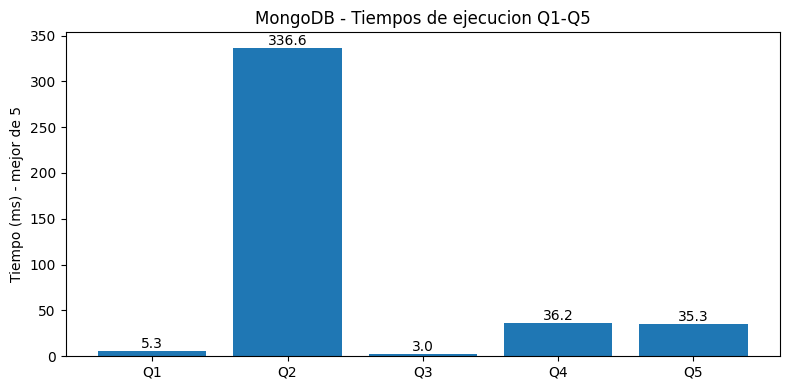

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.bar(tiempos["query"], tiempos["best_ms"])
plt.ylabel("Tiempo (ms) - mejor de 5")
plt.title("MongoDB - Tiempos de ejecucion Q1-Q5")
for i, v in enumerate(tiempos["best_ms"]):
    plt.text(i, v, f"{v:.1f}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

In [ ]:
tiempos.to_csv("tiempos_mongodb.csv", index=False)
print("Guardado en tiempos_mongodb.csv")
tiempos

Guardado en tiempos_mongodb.csv


,query,tipo,rows,best_ms,avg_ms
0,Q1,Textual (relevancia),20,5.29,5.44
1,Q2,Textual con exclusion,20,336.63,352.39
2,Q3,Ordenamiento,10,3.03,3.37
3,Q4,Agregacion (shard key),75,36.18,37.08
4,Q5,Agregacion (no shard key),12,35.33,36.14
